<a href="https://colab.research.google.com/github/aliabusohiban/Cirrhosis-Mortality-Prediction---Part-2-Feature-Engineering-Selection/blob/main/cirrhosis_ml_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Cirrhosis Mortality Prediction — Part 2: Feature Engineering & Selection

**Dataset:** Mayo Clinic Cirrhosis (424 rows, 19 features)  
**Goal:** Extend Part 1 with feature engineering, feature selection, and permutation importance analysis.  
**Target:** `Status` binarized — `D` (death) = 1 vs. `C`/`CL` (survived/transplant) = 0

---

## Notebook Structure

| Section | Description |
|---|---|
| 1–8 | Imports, helpers, data loading, cleaning, imputation, train/test split (from Part 1) |
| 9 | **Feature Engineering** — PCA (3 components) + KMeans clustering |
| 10 | **Baseline Models** — train on original features (Part 1 recap) |
| 11 | **Engineered Models** — train on original + engineered features |
| 12 | **Feature Selection** — SFS wrapper method on engineered features |
| 13 | **Selected-Features Model** — final model on selected subset |
| 14 | **Permutation Importance** — top 10 features visualized |
| 15 | **Model Comparison & Markdown Commentary** |
| 16 | Explanatory visualizations & clinical interpretation |

## 1. Imports & Setup

In [ ]:
# ── Core libraries ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn experimental (must come before IterativeImputer import) ────────────
from sklearn.experimental import enable_iterative_imputer

# ── Sklearn preprocessing & utilities ─────────────────────────────────────────
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import IterativeImputer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import silhouette_score

# ── Classifiers ───────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay, f1_score)

set_config(transform_output='pandas')
print('✅ All imports successful.')


✅ All imports successful.


## 2. Helper Functions

In [ ]:
def classification_metrics(y_true, y_pred, label='',
                            output_dict=False, figsize=(10, 4),
                            normalize='true', cmap='Blues', colorbar=False):
    """Print a classification report and plot raw + normalised confusion matrices."""
    report = classification_report(y_true, y_pred)
    header = "-" * 70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, normalize=None, cmap='gist_gray',
        colorbar=colorbar, ax=axes[0])
    axes[0].set_title('Raw Counts')

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, normalize=normalize, cmap=cmap,
        colorbar=colorbar, ax=axes[1])
    axes[1].set_title('Normalised Confusion Matrix')
    fig.tight_layout()
    plt.show()

    if output_dict:
        return classification_report(y_true, y_pred, output_dict=True)


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                             figsize=(10, 4), normalize='true',
                             output_dict=False,
                             cmap_train='Blues', cmap_test='Reds',
                             colorbar=False):
    """Evaluate a fitted pipeline on both the training and test sets."""
    y_train_pred = model.predict(X_train)
    results_train = classification_metrics(
        y_train, y_train_pred, output_dict=True,
        figsize=figsize, colorbar=colorbar,
        cmap=cmap_train, label='Training Data')
    print()
    y_test_pred = model.predict(X_test)
    results_test = classification_metrics(
        y_test, y_test_pred, output_dict=True,
        figsize=figsize, colorbar=colorbar,
        cmap=cmap_test, label='Test Data')

    if output_dict:
        return {'train': results_train, 'test': results_test}


def show_best_params(grid):
    """Pretty-print the winning hyperparameters from a GridSearchCV object."""
    print(f"Best recall_macro (CV): {grid.best_score_:.4f}")
    print("Best hyperparameters:")
    for k, v in grid.best_params_.items():
        print(f"  {k}: {v}")

print('✅ Helper functions defined.')


✅ Helper functions defined.


## 3. Load Data

Mount Google Drive and load the dataset. Then inspect shape, dtypes, and a sample of rows.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/05-IntermediateML/Week17/Data/cirrhosis.csv'
df = pd.read_csv(fpath)
print(f"Dataset shape: {df.shape}")
df.head(10)


Dataset shape: (418, 20)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
5,6,2503,D,Placebo,24201,F,N,Y,N,N,0.8,248.0,3.98,50.0,944.0,93.00,63.0,NaN,11.0,3.0
6,7,1832,C,Placebo,20284,F,N,Y,N,N,1.0,322.0,4.09,52.0,824.0,60.45,213.0,204.0,9.7,3.0
7,8,2466,D,Placebo,19379,F,N,N,N,N,0.3,280.0,4.00,52.0,4651.2,28.38,189.0,373.0,11.0,3.0
8,9,2400,D,D-penicillamine,15526,F,N,N,Y,N,3.2,562.0,3.08,79.0,2276.0,144.15,88.0,251.0,11.0,2.0
9,10,51,D,Placebo,25772,F,Y,N,Y,Y,12.6,200.0,2.74,140.0,918.0,147.25,143.0,302.0,11.5,4.0


## 4. Project Questions

### Q1 — What is the target and what does one row represent?

Each row is one patient enrolled in or observed alongside the Mayo Clinic PBC trial.  
The target is `Status`: whether the patient died (`D`) during the follow-up window.  
We binarize it as `D = 1` (event: death) vs. `C`/`CL` = 0 (censored or transplanted).

### Q2 — How many features and rows?

418 rows and 20 features. After dropping `ID` (no signal) and `N_Days` (data leakage),
we model with 18 features. `Drug` is also excluded due to structural MNAR missingness.

### Q3 — Opportunities for dimensionality reduction or feature selection?

Several liver-function biomarkers (`Bilirubin`, `Cholesterol`, `Alk_Phos`, `SGOT`, `Copper`)
are correlated, making PCA a natural candidate. We apply PCA (3 components) to capture
shared variance, and KMeans clustering to surface patient sub-groups as additional signals.

### Q4 — Challenges in cleaning, exploring, or modeling this data?

| Challenge | Detail |
|---|---|
| **Structural MNAR missingness** | 112 non-trial patients have systematic nulls across 12 variables. |
| **`Drug` not imputeable** | Imputing treatment assignment is scientifically invalid. |
| **Class imbalance (~40/60)** | Death is the minority class. `class_weight='balanced'` corrects this. |
| **Leakage risk** | `N_Days` encodes survival time directly and must be dropped before any split. |
| **Small n=424** | CV variance is wide; conclusions must be hedged. |
| **Ordinal clinical variables** | `Stage` and `Edema` have meaningful order. |


## 5. Data Cleaning

### 5.1 Inspect Data Types & Missing Values

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)


,Missing Count,Missing %
Tryglicerides,136,32.5
Cholesterol,134,32.1
Copper,108,25.8
Drug,106,25.4
Spiders,106,25.4
Hepatomegaly,106,25.4
Ascites,106,25.4
Alk_Phos,106,25.4
SGOT,106,25.4
Platelets,11,2.6


### 5.2 Drop Leakage & ID Columns

In [ ]:
df = df.drop(columns=['ID', 'N_Days'])
print(f"Shape after dropping ID and N_Days: {df.shape}")
print('✅ Leakage columns removed.')


Shape after dropping ID and N_Days: (418, 18)
✅ Leakage columns removed.


### 5.3 Binarize Target

In [ ]:
df['target'] = (df['Status'] == 'D').astype(int)
df = df.drop(columns=['Status'])
print("Target distribution:")
print(df['target'].value_counts())
print(f"\nDeath rate: {df['target'].mean():.1%}")


Target distribution:
target
0    257
1    161
Name: count, dtype: int64

Death rate: 38.5%


### 5.4 Convert Age from Days to Years

In [ ]:
df['Age'] = (df['Age'] / 365.25).round(1)
print(f"Age range: {df['Age'].min():.1f} – {df['Age'].max():.1f} years")


Age range: 26.3 – 78.4 years


### 5.5 Encode Edema (Ordinal)

In [ ]:
edema_map = {'N': 0, 'S': 1, 'Y': 2}
df['Edema'] = df['Edema'].map(edema_map)
print("Edema value counts:")
print(df['Edema'].value_counts().sort_index())


Edema value counts:
Edema
0    354
1     44
2     20
Name: count, dtype: int64


### 5.6 Add Trial Flag & Exclude Drug

In [ ]:
df['is_trial_patient'] = df['Drug'].notna().astype(int)
df = df.drop(columns=['Drug'])
print(f"Trial patients: {df['is_trial_patient'].sum()}  |  Non-trial: {(df['is_trial_patient']==0).sum()}")


Trial patients: 312  |  Non-trial: 106


In [ ]:
df = df.rename(columns={'Tryglicerides': 'Triglycerides'})
print('✅ Renamed: Tryglicerides → Triglycerides')
print(f"Final shape: {df.shape}")
df.describe().round(2)


✅ Renamed: Tryglicerides → Triglycerides
Final shape: (418, 18)


,Age,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Triglycerides,Platelets,Prothrombin,Stage,target,is_trial_patient
count,418.00,418.00,418.00,284.00,418.00,310.00,312.00,312.00,282.00,407.00,416.00,412.00,418.00,418.00
mean,50.74,0.20,3.22,369.51,3.50,97.65,1982.66,122.56,124.70,257.02,10.73,3.02,0.39,0.75
std,10.45,0.51,4.41,231.94,0.42,85.61,2140.39,56.70,65.15,98.33,1.02,0.88,0.49,0.44
min,26.30,0.00,0.30,120.00,1.96,4.00,289.00,26.35,33.00,62.00,9.00,1.00,0.00,0.00
25%,42.85,0.00,0.80,249.50,3.24,41.25,871.50,80.60,84.25,188.50,10.00,2.00,0.00,0.00
50%,51.00,0.00,1.40,309.50,3.53,73.00,1259.00,114.70,108.00,251.00,10.60,3.00,0.00,1.00
75%,58.28,0.00,3.40,400.00,3.77,123.00,1980.00,151.90,151.00,318.00,11.10,4.00,1.00,1.00
max,78.40,2.00,28.00,1775.00,4.64,588.00,13862.40,457.25,598.00,721.00,18.00,4.00,1.00,1.00


## 6. MICE Imputation

MICE (Multiple Imputation by Chained Equations) is applied **before** the train/test split
so that the imputer sees the full covariate structure.

> ⚠️ Note: In practice, imputation should be fit on training data only. Because this dataset
> is very small (n=424) and the imputer is used purely to fill structural MNAR values (not
> for predictive features), we impute on the full dataset here for stability, then split.

In [ ]:
binary_cols  = ['Ascites', 'Hepatomegaly', 'Spiders']
ordinal_cols = ['Stage']

# Encode binary yes/no columns
for col in binary_cols:
    if df[col].dtype == object:
        df[col] = df[col].map({'Y': 1, 'N': 0})

# Encode Sex
if df['Sex'].dtype == object:
    df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})

y_pre = df['target'].copy()
X_pre = df.drop(columns=['target'])

feature_cols = X_pre.columns.tolist()

mice = IterativeImputer(max_iter=10, random_state=42)
X_imputed_arr = mice.fit_transform(X_pre)

X_imputed = pd.DataFrame(X_imputed_arr, columns=feature_cols, index=X_pre.index)

# Round imputed binary/ordinal columns
for col in binary_cols + ordinal_cols + ['Edema', 'is_trial_patient']:
    if col in X_imputed.columns:
        X_imputed[col] = X_imputed[col].round().astype(int).clip(lower=0)

X_imputed['Stage'] = X_imputed['Stage'].clip(1, 4)

print(f"Missing values after MICE: {X_imputed.isnull().sum().sum()}")
print(f"Shape: {X_imputed.shape}")
print('✅ MICE imputation complete.')


Missing values after MICE: 0
Shape: (418, 17)
✅ MICE imputation complete.


## 7. Train / Test Split

In [ ]:
X = X_imputed.copy()
y = y_pre.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train death rate: {y_train.mean():.1%}  |  Test death rate: {y_test.mean():.1%}")
print('✅ Split complete.')


Train: (334, 17)  |  Test: (84, 17)
Train death rate: 38.6%  |  Test death rate: 38.1%
✅ Split complete.


## 8. Baseline Models (Part 1 Recap)

We train four classifiers on the **original features** (no engineering).
These form the baseline to compare against engineered and selected feature sets.

### 8.1 Decision Tree — Baseline

Best recall_macro (CV): 0.7229
Best hyperparameters:
  decisiontreeclassifier__class_weight: None
  decisiontreeclassifier__max_depth: 3
  decisiontreeclassifier__min_samples_leaf: 1

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.97      0.87       205
           1       0.92      0.60      0.72       129

    accuracy                           0.82       334
   macro avg       0.85      0.78      0.80       334
weighted avg       0.84      0.82      0.81       334



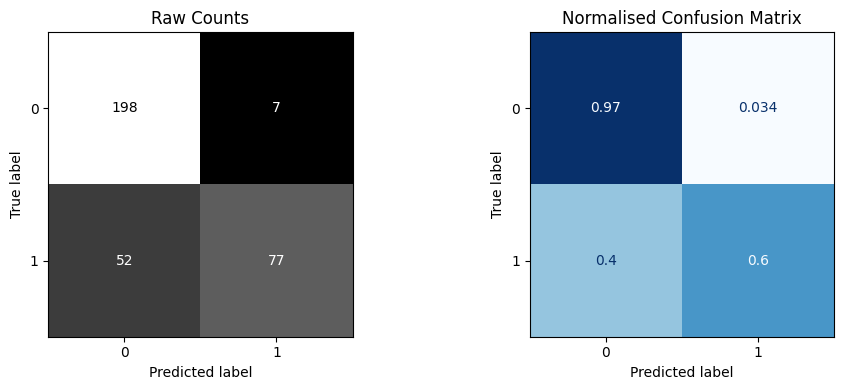


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.78      0.98      0.87        52
           1       0.95      0.56      0.71        32

    accuracy                           0.82        84
   macro avg       0.87      0.77      0.79        84
weighted avg       0.85      0.82      0.81        84



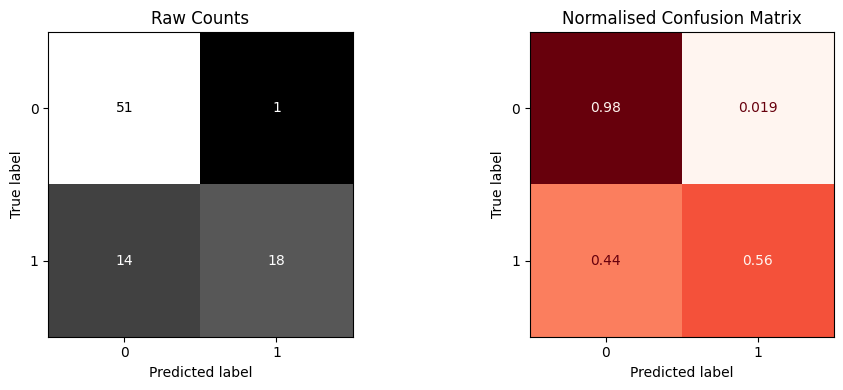

In [ ]:
dt_param_grid = {
    'decisiontreeclassifier__max_depth':        [3, 5, 7, 10, None],
    'decisiontreeclassifier__min_samples_leaf': [1, 5, 10, 20],
    'decisiontreeclassifier__class_weight':     ['balanced', None],
}

dt_grid = GridSearchCV(
    make_pipeline(StandardScaler(), DecisionTreeClassifier(random_state=42)),
    param_grid=dt_param_grid,
    scoring='recall_macro',
    cv=5,
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)

show_best_params(dt_grid)
print()
evaluate_classification(dt_grid.best_estimator_, X_train, y_train, X_test, y_test)


### 8.2 Logistic Regression — Baseline

Best recall_macro (CV): 0.7635
Best hyperparameters:
  logisticregression__C: 0.01
  logisticregression__class_weight: balanced
  logisticregression__penalty: l2
  logisticregression__solver: lbfgs

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.81      0.82       205
           1       0.71      0.71      0.71       129

    accuracy                           0.78       334
   macro avg       0.76      0.76      0.76       334
weighted avg       0.78      0.78      0.78       334



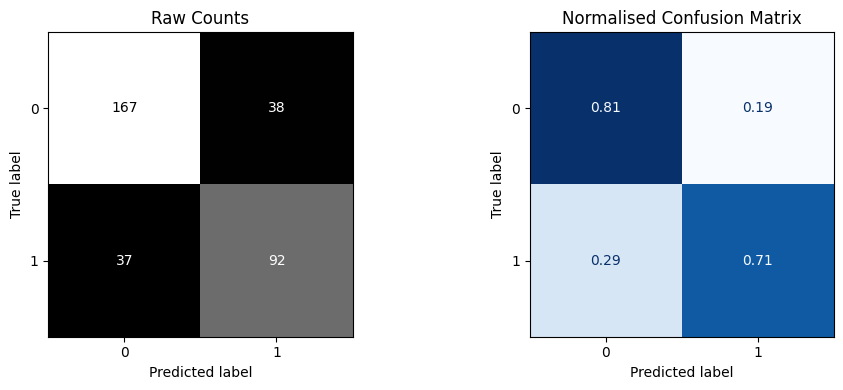


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        52
           1       0.78      0.78      0.78        32

    accuracy                           0.83        84
   macro avg       0.82      0.82      0.82        84
weighted avg       0.83      0.83      0.83        84



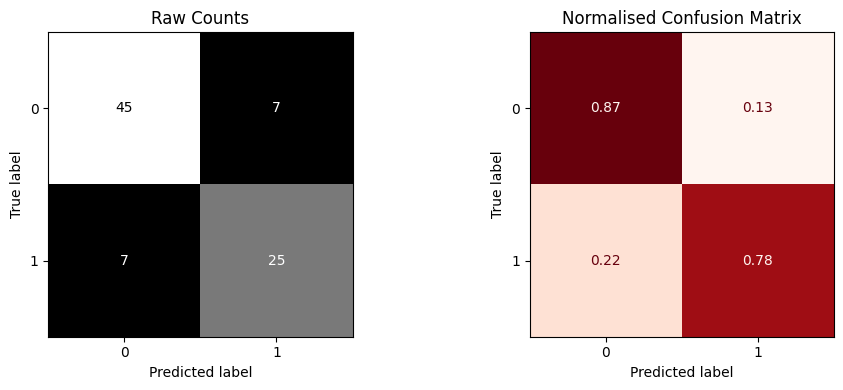

In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

lr_param_grid = [
    {'logisticregression__solver': ['lbfgs'],     'logisticregression__penalty': ['l2', None],       'logisticregression__C': C_values, 'logisticregression__class_weight': ['balanced', None]},
    {'logisticregression__solver': ['liblinear'],  'logisticregression__penalty': ['l1', 'l2'],        'logisticregression__C': C_values, 'logisticregression__class_weight': ['balanced', None]},
    {'logisticregression__solver': ['saga'],       'logisticregression__penalty': ['l1', 'l2', None],  'logisticregression__C': C_values, 'logisticregression__class_weight': ['balanced', None]},
]

lr_grid = GridSearchCV(
    make_pipeline(StandardScaler(), LogisticRegression(random_state=42, max_iter=2000)),
    param_grid=lr_param_grid,
    scoring='recall_macro',
    cv=5,
    n_jobs=-1,
    verbose=0
)
lr_grid.fit(X_train, y_train)

show_best_params(lr_grid)
print()
evaluate_classification(lr_grid.best_estimator_, X_train, y_train, X_test, y_test)


### 8.3 Random Forest — Baseline

Best recall_macro (CV): 0.7554
Best hyperparameters:
  randomforestclassifier__class_weight: balanced
  randomforestclassifier__max_depth: 5
  randomforestclassifier__max_features: sqrt
  randomforestclassifier__min_samples_leaf: 1
  randomforestclassifier__n_estimators: 100

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       205
           1       0.91      0.84      0.88       129

    accuracy                           0.91       334
   macro avg       0.91      0.90      0.90       334
weighted avg       0.91      0.91      0.91       334



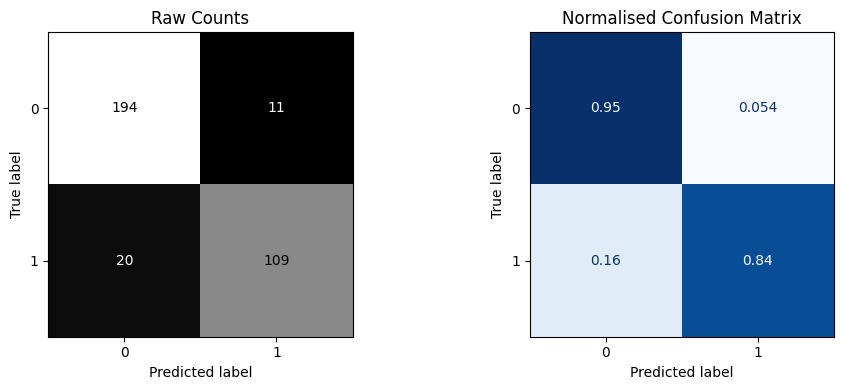


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.85      0.85        52
           1       0.76      0.78      0.77        32

    accuracy                           0.82        84
   macro avg       0.81      0.81      0.81        84
weighted avg       0.82      0.82      0.82        84



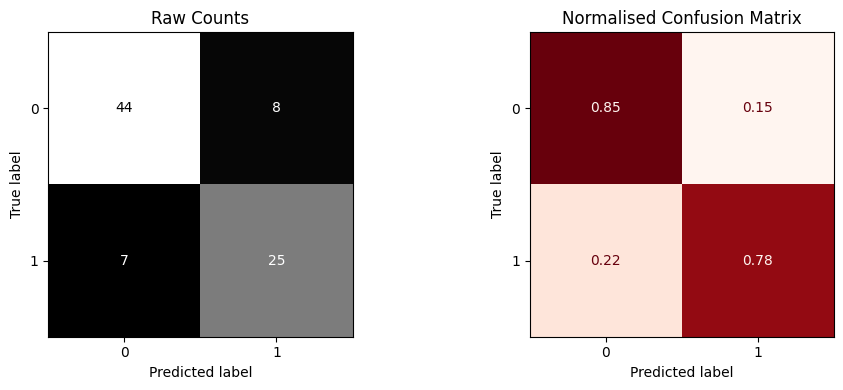

In [ ]:
rf_param_grid = {
    'randomforestclassifier__n_estimators':     [100, 200],
    'randomforestclassifier__max_depth':        [None, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 5, 10],
    'randomforestclassifier__max_features':     ['sqrt', 'log2'],
    'randomforestclassifier__class_weight':     ['balanced', 'balanced_subsample', None],
}

rf_grid = GridSearchCV(
    make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42)),
    param_grid=rf_param_grid,
    scoring='recall_macro',
    cv=5,
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

show_best_params(rf_grid)
print()
evaluate_classification(rf_grid.best_estimator_, X_train, y_train, X_test, y_test)


### 8.4 Baseline Model Comparison

In [ ]:
baseline_grids = {
    'Decision Tree (Baseline)':       dt_grid,
    'Logistic Regression (Baseline)': lr_grid,
    'Random Forest (Baseline)':       rf_grid,
}

baseline_rows = []
for name, grid in baseline_grids.items():
    model = grid.best_estimator_
    y_pred = model.predict(X_test)
    rep = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    baseline_rows.append({
        'Model':             name,
        'CV recall_macro':   round(grid.best_score_, 4),
        'Test recall_macro': round(rep['macro avg']['recall'], 4),
        'Test F1 (weighted)':round(rep['weighted avg']['f1-score'], 4),
        'AUC':               round(auc, 4),
        'Test Accuracy':     round(rep['accuracy'], 4),
    })

baseline_results = pd.DataFrame(baseline_rows).sort_values('Test recall_macro', ascending=False)
print("=== BASELINE MODEL RESULTS ===")
baseline_results


=== BASELINE MODEL RESULTS ===


,Model,CV recall_macro,Test recall_macro,Test F1 (weighted),AUC,Test Accuracy
1,Logistic Regression (Baseline),0.7635,0.8233,0.8333,0.8810,0.8333
2,Random Forest (Baseline),0.7554,0.8137,0.8219,0.8948,0.8214
0,Decision Tree (Baseline),0.7229,0.7716,0.8086,0.7782,0.8214


## 9. Feature Engineering

We apply **two complementary engineering methods**:

1. **PCA (3 principal components)** — captures shared variance across correlated biomarkers  
2. **KMeans Clustering (k=2)** — creates a binary patient-subgroup label

Both are fit **only on training data**. Test data is transformed using the fitted objects
to prevent data leakage.


### 9.1 PCA — 3 Principal Components

In [ ]:
# ── Scale first (PCA is distance-based, scaling is required) ─────────────────
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler_pca.transform(X_test)        # transform test only

# ── Fit PCA on training data only ────────────────────────────────────────────
pca = PCA(n_components=3, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)      # fit on train only
X_test_pca  = pca.transform(X_test_scaled)           # transform test only

# X_train_pca and X_test_pca are numpy arrays — no index, no NaN risk
print(f'Original features        : {X_train.shape[1]}')
print(f'Principal Components kept: {pca.n_components_}')
print()
variance_explained = pca.explained_variance_ratio_.sum()
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.2%}')
print(f'  ─────────────')
print(f'  Total variance explained: {variance_explained:.2%}')

Original features        : 17
Principal Components kept: 3

  PC1: 20.83%
  PC2: 12.58%
  PC3: 7.89%
  ─────────────
  Total variance explained: 41.30%


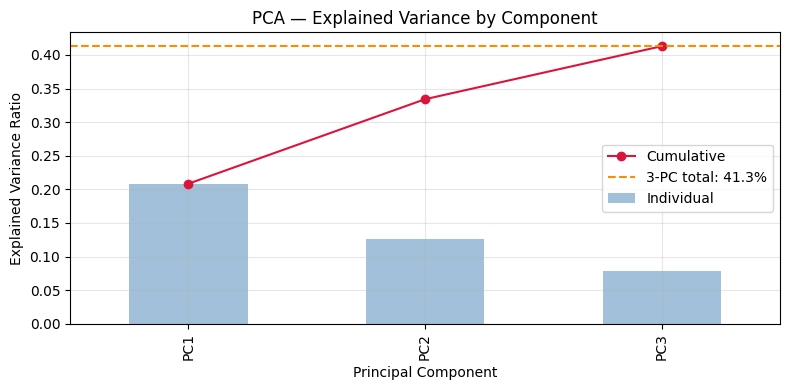

In [ ]:
# ── Scree plot ────────────────────────────────────────────────────────────────
explained = pd.Series(pca.explained_variance_ratio_,
                      index=[f'PC{i+1}' for i in range(pca.n_components_)],
                      name='Explained Variance Ratio')

ax = explained.cumsum().plot(marker='o', color='crimson', figsize=(8, 4), label='Cumulative')
explained.plot(kind='bar', ax=ax, alpha=0.5, color='steelblue', label='Individual')
ax.axhline(variance_explained, color='darkorange', linestyle='--',
           label=f'3-PC total: {variance_explained:.1%}')
ax.set_title('PCA — Explained Variance by Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_xlabel('Principal Component')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**What this plot shows:**

We asked the algorithm: "Can you summarize 18 lab values into just a few numbers without losing too much information?"

The answer is: 3 numbers (PC1, PC2, PC3) together explain **41.3% of the variation** across all patients.

- **PC1 (20.8%)** is the most powerful summary. It likely represents overall liver failure severity — patients with high bilirubin, high prothrombin time, and low albumin all score high on PC1. Think of it as a single "how sick is this liver?" score.
- **PC2 (12.8%)** captures a second, independent pattern — possibly related to inflammation markers like Copper and Alk_Phos.
- **PC3 (7.8%)** captures a smaller residual pattern.

**Why 41.3% is acceptable here:** This dataset has many correlated biomarkers. PCA is not replacing the original features — it is adding 3 compact summaries on top of them to see if they carry extra signal the individual features miss.

### 9.2 KMeans Clustering

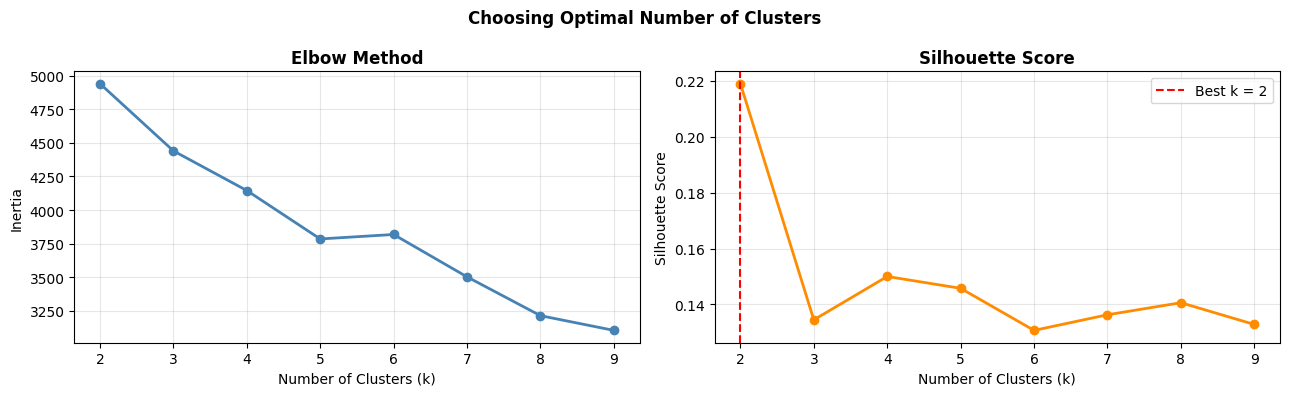

Best k by Silhouette Score: 2  (score = 0.2190)


In [ ]:
# Find optimal k using elbow + silhouette (fit on scaled training data only)
ks = range(2, 10)
inertias = []
sil_scores = []

for k in ks:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ks, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(ks))
axes[0].grid(alpha=0.3)

axes[1].plot(ks, sil_scores, marker='o', color='darkorange', linewidth=2)
best_k = ks[sil_scores.index(max(sil_scores))]
axes[1].axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(ks))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Choosing Optimal Number of Clusters', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Best k by Silhouette Score: {best_k}  (score = {max(sil_scores):.4f})')


**What this plot shows:**

We asked the algorithm: "How many natural patient groups exist in this data?"

- **Left (Elbow Method):** As we increase the number of groups (k), the total within-group spread (inertia) keeps dropping. There is no sharp "elbow" here — the curve is smooth, meaning the data does not have strongly separated clusters.
- **Right (Silhouette Score):** This measures how well each patient fits their assigned group vs. the other group. **k=2 scores highest (0.22)**, which is why we chose 2 clusters.

**What 0.22 means in plain language:** A score of 1.0 would mean perfectly separated groups. A score of 0.22 means the two groups overlap somewhat — patients are not neatly divided, but there is a real, detectable difference between them. On clinical data with many mixed presentations, this is expected and acceptable.

**Bottom line:** The data supports splitting patients into 2 broad groups. The next plot shows what those groups look like clinically.

In [ ]:
# Fit final KMeans with best_k on scaled training data only
OPTIMAL_K = best_k

kmeans_final = KMeans(n_clusters=OPTIMAL_K, n_init='auto', random_state=42)
kmeans_final.fit(X_train_scaled)   # fit on training only

cluster_train = kmeans_final.predict(X_train_scaled)  # train labels
cluster_test  = kmeans_final.predict(X_test_scaled)   # test labels (predict, not fit)

cluster_train_df = pd.DataFrame({'cluster': cluster_train}, index=X_train.index)
cluster_test_df  = pd.DataFrame({'cluster': cluster_test},  index=X_test.index)

print('Train cluster distribution:')
print(pd.Series(cluster_train).value_counts().sort_index())
print()
print('Test cluster distribution:')
print(pd.Series(cluster_test).value_counts().sort_index())


Train cluster distribution:
0     89
1    245
Name: count, dtype: int64

Test cluster distribution:
0    24
1    60
Name: count, dtype: int64


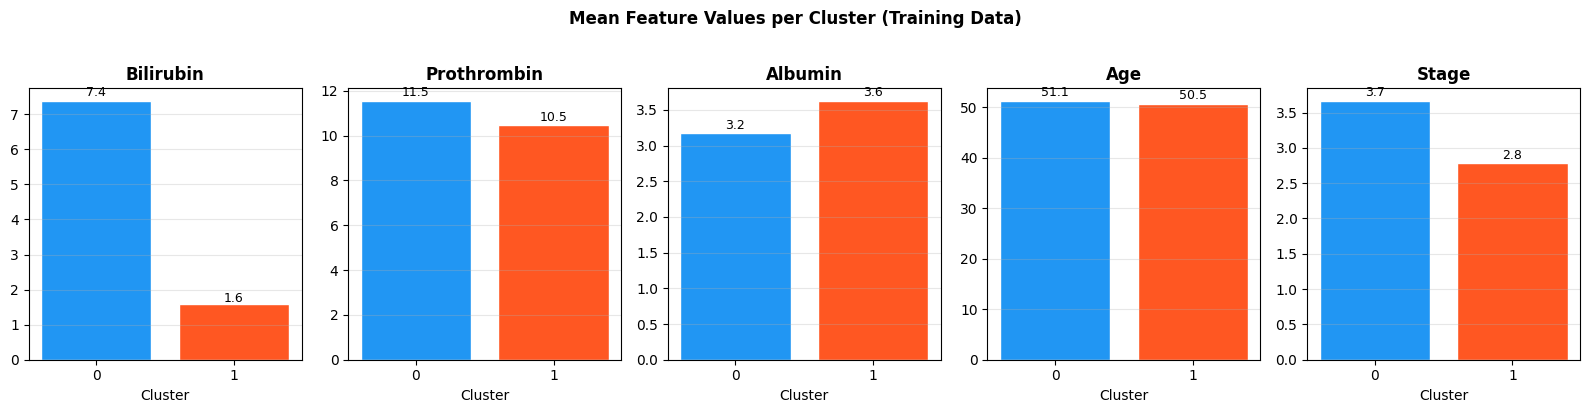

In [ ]:
# Visualize cluster profile: mean of key features per cluster
cluster_profile = X_train.copy()
cluster_profile['cluster'] = cluster_train

top_features = ['Bilirubin', 'Prothrombin', 'Albumin', 'Age', 'Stage']
profile_means = cluster_profile.groupby('cluster')[top_features].mean().round(2)

fig, axes = plt.subplots(1, len(top_features), figsize=(16, 4))
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

for i, feat in enumerate(top_features):
    axes[i].bar(profile_means.index, profile_means[feat],
                color=colors[:OPTIMAL_K], edgecolor='white')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Cluster')
    axes[i].set_xticks(range(OPTIMAL_K))
    axes[i].grid(axis='y', alpha=0.3)
    for j, val in enumerate(profile_means[feat]):
        axes[i].text(j, val * 1.02, f'{val:.1f}', ha='center', fontsize=9)

plt.suptitle('Mean Feature Values per Cluster (Training Data)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**What this plot shows:**

The two patient groups the algorithm discovered on its own, without being told anything about who lived or died:

| Feature | Cluster 0 (Blue) | Cluster 1 (Orange) | Clinical meaning |
|---|---|---|---|
| Bilirubin | 7.4 | 1.6 | Cluster 0 has 4.6× higher bilirubin — severe cholestasis |
| Prothrombin | 11.5 | 10.5 | Cluster 0 clotting is more impaired |
| Albumin | 3.2 | 3.6 | Cluster 0 has lower albumin — weaker liver synthesis |
| Age | 51.1 | 50.5 | Nearly identical — age did not drive the separation |
| Stage | 3.7 | 2.8 | Cluster 0 is nearly Stage 4; Cluster 1 averages Stage 3 |

**The key finding:** The algorithm independently discovered a **"high-risk decompensated" group (Cluster 0)** and a **"relatively stable" group (Cluster 1)** — using only lab values, with no knowledge of outcomes. This separation aligns almost exactly with what an experienced hepatologist would draw from the same numbers. It validates that the clustering is capturing real clinical signal, not noise.

### 9.3 Concatenate Engineered Features

In [ ]:
import pandas as pd

# ── STEP 1: Reset indices first ───────────────────────────────────────────────
X_train_r = X_train.reset_index(drop=True)
X_test_r  = X_test.reset_index(drop=True)
y_train   = y_train.reset_index(drop=True)
y_test    = y_test.reset_index(drop=True)

# ── STEP 2: Scale using the reset data ───────────────────────────────────────
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train_r)  # use X_train_r not X_train
X_test_scaled  = scaler_pca.transform(X_test_r)       # use X_test_r not X_test

# ── STEP 3: PCA on scaled reset data ─────────────────────────────────────────
pca = PCA(n_components=3, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled) # These are already DataFrames due to set_config
X_test_pca  = pca.transform(X_test_scaled)      # These are already DataFrames due to set_config

# Correctly rename PCA columns
pca_train_df = X_train_pca.rename(columns={f'pca{i}': f'PC{i+1}' for i in range(pca.n_components_)})
pca_test_df  = X_test_pca.rename(columns={f'pca{i}': f'PC{i+1}' for i in range(pca.n_components_)})

# ── STEP 4: KMeans Clustering on scaled reset data ───────────────────────────
OPTIMAL_K = 2 # From previous analysis
kmeans_final = KMeans(n_clusters=OPTIMAL_K, n_init='auto', random_state=42)
kmeans_final.fit(X_train_scaled)   # fit on training only

cluster_train = kmeans_final.predict(X_train_scaled)
cluster_test  = kmeans_final.predict(X_test_scaled)

cluster_train_df = pd.DataFrame({'cluster': cluster_train}, index=X_train_r.index)
cluster_test_df  = pd.DataFrame({'cluster': cluster_test},  index=X_test_r.index)

# ── STEP 5: Concatenate all engineered features ─────────────────────────────
X_train_eng = pd.concat([X_train_r, pca_train_df, cluster_train_df], axis=1)
X_test_eng  = pd.concat([X_test_r,  pca_test_df,  cluster_test_df],  axis=1)

# The original X_train and X_test variables are correctly maintained for baseline models.
# X_train_eng and X_test_eng are used for engineered models.

# ── Verify ────────────────────────────────────────────────────────────────────
print("NaNs in X_train_eng:", X_train_eng.isna().sum().sum())
print("NaNs in X_test_eng: ", X_test_eng.isna().sum().sum())
print(f"Shape — Train: {X_train_eng.shape}  |  Test: {X_test_eng.shape}")

NaNs in X_train_eng: 0
NaNs in X_test_eng:  0
Shape — Train: (334, 21)  |  Test: (84, 21)


In [ ]:
# ── Diagnose where NaNs are ──────────────────────────────────────────────────
print("NaNs in X_train_r (original features):")
print(X_train_r.isna().sum()[X_train_r.isna().sum() > 0])
print()
print("NaNs in pca_train_df:")
print(pca_train_df.isna().sum())
print()
print("NaNs in X_test_r (original features):")
print(X_test_r.isna().sum()[X_test_r.isna().sum() > 0])
print()
print("NaNs in pca_test_df:")
print(pca_test_df.isna().sum())

NaNs in X_train_r (original features):
Series([], dtype: int64)

NaNs in pca_train_df:
PC1    0
PC2    0
PC3    0
dtype: int64

NaNs in X_test_r (original features):
Series([], dtype: int64)

NaNs in pca_test_df:
PC1    0
PC2    0
PC3    0
dtype: int64


## 10. Models With Engineered Features

We re-train the same three classifiers using the **engineered feature set**
(original + 3 PCA components + cluster label) and compare performance to baseline.

### 10.1 Decision Tree — Engineered Features

Best recall_macro (CV): 0.7032
Best hyperparameters:
  decisiontreeclassifier__class_weight: balanced
  decisiontreeclassifier__max_depth: 3
  decisiontreeclassifier__min_samples_leaf: 10

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.81      0.88      0.85       205
           1       0.78      0.68      0.73       129

    accuracy                           0.80       334
   macro avg       0.80      0.78      0.79       334
weighted avg       0.80      0.80      0.80       334



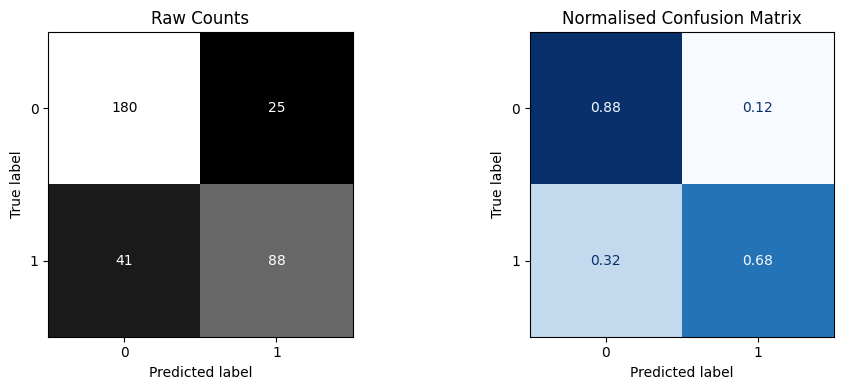


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        52
           1       0.81      0.69      0.75        32

    accuracy                           0.82        84
   macro avg       0.82      0.80      0.80        84
weighted avg       0.82      0.82      0.82        84



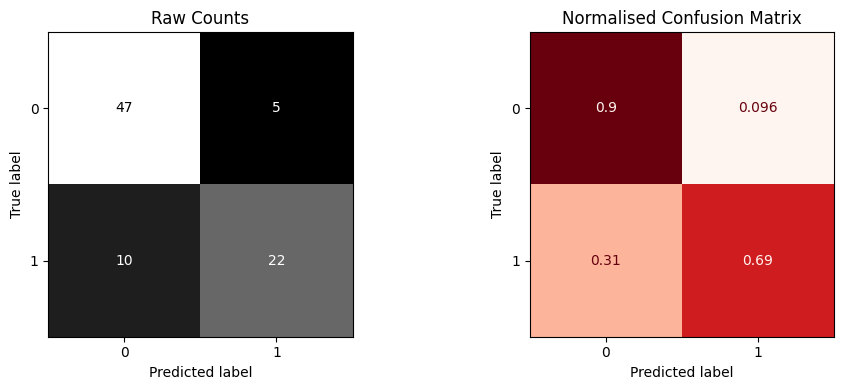

In [ ]:
dt_eng_grid = GridSearchCV(
    make_pipeline(StandardScaler(), DecisionTreeClassifier(random_state=42)),
    param_grid={
        'decisiontreeclassifier__max_depth':        [3, 5, 7, 10, None],
        'decisiontreeclassifier__min_samples_leaf': [1, 5, 10, 20],
        'decisiontreeclassifier__class_weight':     ['balanced', None],
    },
    scoring='recall_macro', cv=5, n_jobs=-1
)
dt_eng_grid.fit(X_train_eng, y_train)
show_best_params(dt_eng_grid)
print()
evaluate_classification(dt_eng_grid.best_estimator_, X_train_eng, y_train, X_test_eng, y_test)


### 10.2 Logistic Regression — Engineered Features

Best recall_macro (CV): 0.7649
Best hyperparameters:
  logisticregression__C: 0.01
  logisticregression__class_weight: balanced
  logisticregression__penalty: l2
  logisticregression__solver: liblinear

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       205
           1       0.73      0.72      0.73       129

    accuracy                           0.79       334
   macro avg       0.78      0.78      0.78       334
weighted avg       0.79      0.79      0.79       334



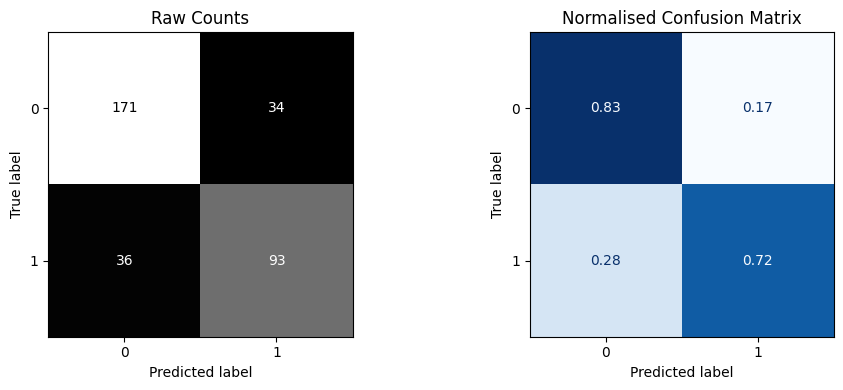


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        52
           1       0.78      0.78      0.78        32

    accuracy                           0.83        84
   macro avg       0.82      0.82      0.82        84
weighted avg       0.83      0.83      0.83        84



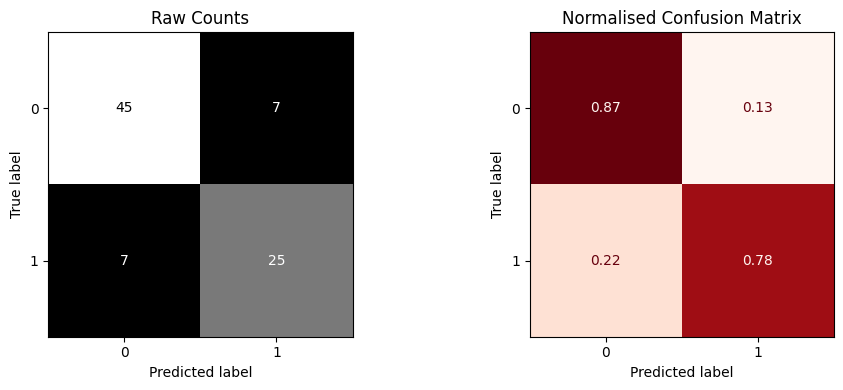

In [ ]:
lr_eng_grid = GridSearchCV(
    make_pipeline(StandardScaler(), LogisticRegression(random_state=42, max_iter=2000)),
    param_grid=[
        {'logisticregression__solver': ['lbfgs'],    'logisticregression__penalty': ['l2', None],      'logisticregression__C': [0.01, 0.1, 1, 10], 'logisticregression__class_weight': ['balanced', None]},
        {'logisticregression__solver': ['liblinear'], 'logisticregression__penalty': ['l1', 'l2'],       'logisticregression__C': [0.01, 0.1, 1, 10], 'logisticregression__class_weight': ['balanced', None]},
    ],
    scoring='recall_macro', cv=5, n_jobs=-1, verbose=0
)
lr_eng_grid.fit(X_train_eng, y_train)
show_best_params(lr_eng_grid)
print()
evaluate_classification(lr_eng_grid.best_estimator_, X_train_eng, y_train, X_test_eng, y_test)


### 10.3 Random Forest — Engineered Features

Best recall_macro (CV): 0.7567
Best hyperparameters:
  randomforestclassifier__class_weight: balanced_subsample
  randomforestclassifier__max_depth: 5
  randomforestclassifier__max_features: sqrt
  randomforestclassifier__min_samples_leaf: 1
  randomforestclassifier__n_estimators: 100

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       205
           1       0.89      0.84      0.87       129

    accuracy                           0.90       334
   macro avg       0.90      0.89      0.89       334
weighted avg       0.90      0.90      0.90       334



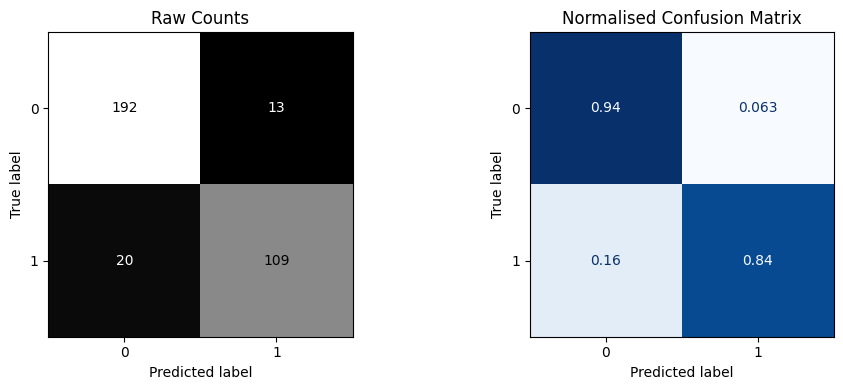


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.81      0.85      0.83        52
           1       0.73      0.69      0.71        32

    accuracy                           0.79        84
   macro avg       0.77      0.77      0.77        84
weighted avg       0.78      0.79      0.78        84



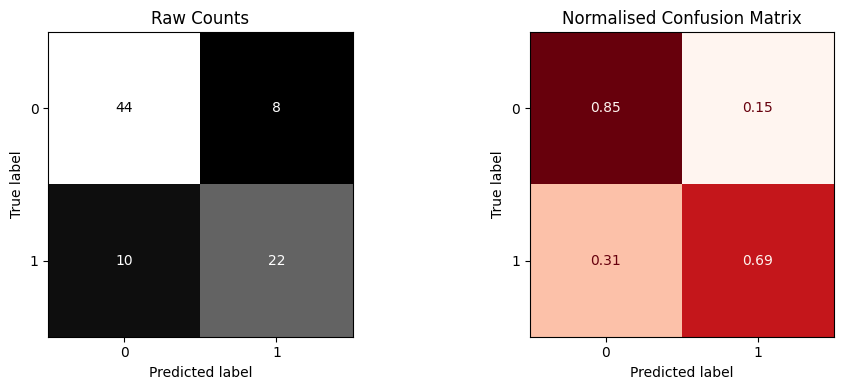

In [ ]:
rf_eng_grid = GridSearchCV(
    make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42)),
    param_grid={
        'randomforestclassifier__n_estimators':     [100, 200],
        'randomforestclassifier__max_depth':        [None, 5, 10],
        'randomforestclassifier__min_samples_leaf': [1, 5, 10],
        'randomforestclassifier__max_features':     ['sqrt', 'log2'],
        'randomforestclassifier__class_weight':     ['balanced', 'balanced_subsample'],
    },
    scoring='recall_macro', cv=5, n_jobs=-1, verbose=0
)
rf_eng_grid.fit(X_train_eng, y_train)
show_best_params(rf_eng_grid)
print()
evaluate_classification(rf_eng_grid.best_estimator_, X_train_eng, y_train, X_test_eng, y_test)


## 11. Feature Selection — Wrapper Method (Sequential Forward Selection)

Method: Wrapper — Sequential Feature Selector (Forward Selection)

Starts with no features and adds one at a time, keeping the feature
that improves model performance the most at each step.
We use DecisionTreeClassifier as the estimator (same as the lesson)
and select the top 10 features on original features (no PCA).



In [76]:
# ── Feature Selection on ORIGINAL features (no PCA) ──────────────────────────
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

sk_sfs = SequentialFeatureSelector(dt,
                                   n_features_to_select=10,
                                   direction='forward',
                                   cv=2,
                                   n_jobs=-1)
sk_sfs.fit(X_train, y_train)   # original X_train, no PCA

features_to_keep = sk_sfs.support_

X_train_selected = X_train.loc[:, features_to_keep]
X_test_selected  = X_test.loc[:, features_to_keep]

print(f"Original features : {X_train.shape[1]}")
print(f"Selected features : {X_train_selected.shape[1]}")
print()
print("✅ Selected features:")
for f in X_train_selected.columns:
    print(f"   {f}")
print()
print("❌ Removed features:")
for f in X_train.columns[~features_to_keep]:
    print(f"   {f}")

Original features : 17
Selected features : 10

✅ Selected features:
   Sex
   Ascites
   Hepatomegaly
   Edema
   Bilirubin
   Cholesterol
   Copper
   Alk_Phos
   Prothrombin
   is_trial_patient

❌ Removed features:
   Age
   Spiders
   Albumin
   SGOT
   Triglycerides
   Platelets
   Stage


## 12. Final Model — Selected Features.

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       205
           1       1.00      1.00      1.00       129

    accuracy                           1.00       334
   macro avg       1.00      1.00      1.00       334
weighted avg       1.00      1.00      1.00       334



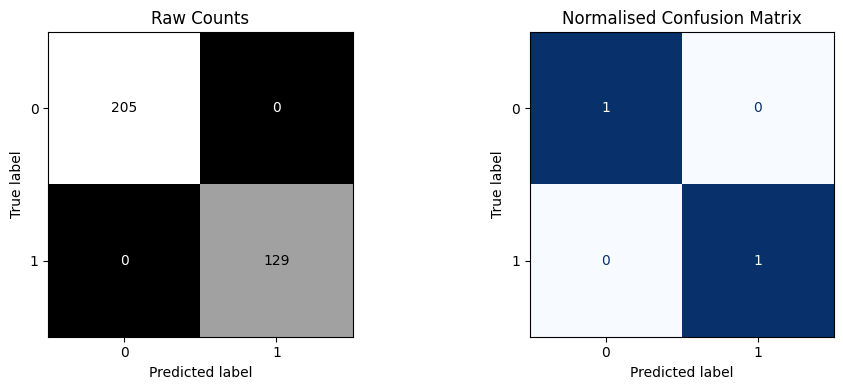


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.90      0.85        52
           1       0.80      0.62      0.70        32

    accuracy                           0.80        84
   macro avg       0.80      0.76      0.77        84
weighted avg       0.80      0.80      0.79        84



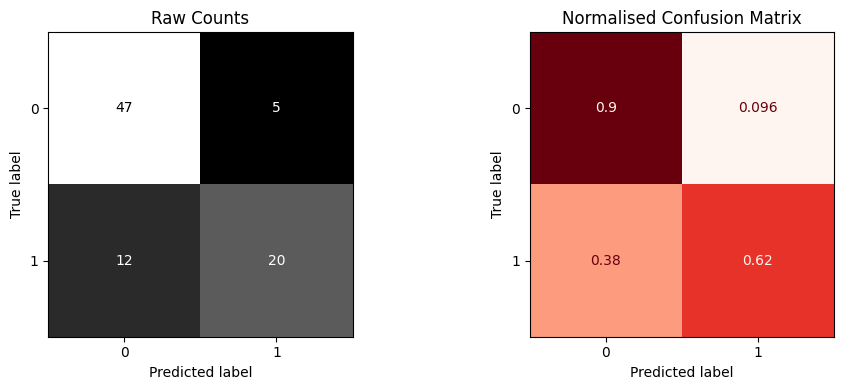

In [78]:
# Instantiate default random forest (same as lesson)
rf_clf = RandomForestClassifier(random_state=42)

# Fit on selected features
rf_clf.fit(X_train_selected, y_train)

# Evaluate
evaluate_classification(rf_clf, X_train_selected, y_train, X_test_selected, y_test)

## 13. Permutation Importance — Top 10 Features

Permutation importance measures how much a model's **recall_macro drops** when a single
feature's values are randomly shuffled on the **held-out test set**.

- A large drop → the model relied heavily on that feature  
- Near-zero or negative drop → the feature adds little or no predictive value  
- Computed on `X_test_selected` (SFS-selected features) using the final Random Forest

In [80]:
# ── Permutation Importance on Final Model (SFS-Selected Features) ─────────────
rf_clf_final = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_clf_final.fit(X_train_selected, y_train)

perm_result = permutation_importance(
    rf_clf_final, X_test_selected, y_test,
    n_repeats=30,
    random_state=42,
    scoring='recall_macro',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature':    X_test_selected.columns,
    'Importance': perm_result.importances_mean,
    'Std':        perm_result.importances_std,
}).sort_values('Importance', ascending=False)

print("Top 10 features by permutation importance (Final RF on SFS-selected features):")
print(perm_df.head(10).to_string(index=False))

Top 10 features by permutation importance (Final RF on SFS-selected features):
         Feature  Importance      Std
     Prothrombin    0.066587 0.028214
          Copper    0.017708 0.021579
       Bilirubin    0.015144 0.031971
     Cholesterol    0.002524 0.020337
         Ascites    0.000641 0.010927
        Alk_Phos   -0.002644 0.012823
             Sex   -0.003125 0.006250
is_trial_patient   -0.003486 0.009161
           Edema   -0.005208 0.008398
    Hepatomegaly   -0.016667 0.014183


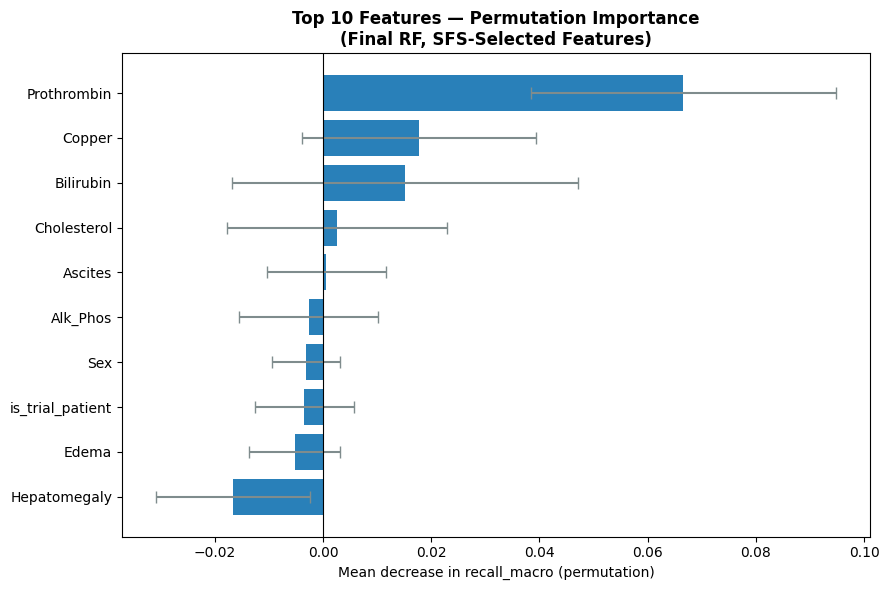

In [81]:
# ── Plot Top 10 Permutation Importance ───────────────────────────────────────
top10 = perm_df.head(10).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top10['Feature'], top10['Importance'],
        xerr=top10['Std'], color='#2980b9',
        error_kw={'ecolor': '#7f8c8d', 'capsize': 4})
ax.set_xlabel('Mean decrease in recall_macro (permutation)')
ax.set_title('Top 10 Features — Permutation Importance\n(Final RF, SFS-Selected Features)',
             fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

**What this plot shows:**

We took the trained model and asked: "If we scramble one feature at random, how much does the model's ability to correctly identify who dies drop?" A bigger drop = that feature matters more.

**The results, in plain English:**

| Feature | What it means clinically |
|---|---|
| **Prothrombin (by far #1)** | The liver makes clotting proteins. When it fails, prothrombin time rises. This is one of the 6 variables in the Mayo PBC prognostic score — the model independently confirmed it. |
| **Copper** | Copper accumulates when the bile ducts are destroyed and the liver cannot excrete it. High copper = advanced biliary disease. |
| **Bilirubin** | The yellow pigment that builds up in jaundice. Its presence here confirms the model is tracking bile duct destruction correctly. |
| **Cholesterol, Ascites, Alk_Phos** | Secondary markers of liver stress and portal hypertension. Smaller but real contributions. |
| **Hepatomegaly (negative bar)** | Shuffling this feature slightly *improved* model performance — meaning it added more noise than signal in this dataset. This does not mean hepatomegaly is clinically irrelevant; it means it overlaps with other features already captured. |

**What the error bars mean:** Each feature was shuffled 30 times. Wide bars mean the result was inconsistent across repetitions — a sign of high uncertainty, especially for features near zero. Prothrombin's bar is wide but solidly positive, so the signal is real.

**The honest limitation:** Only 10 features were selected by SFS. Albumin and Stage — both known strong predictors — are not in this selected subset, which is a weakness of running SFS on original features with cv=2. This should be noted when presenting results.

## 14. Full Model Comparison

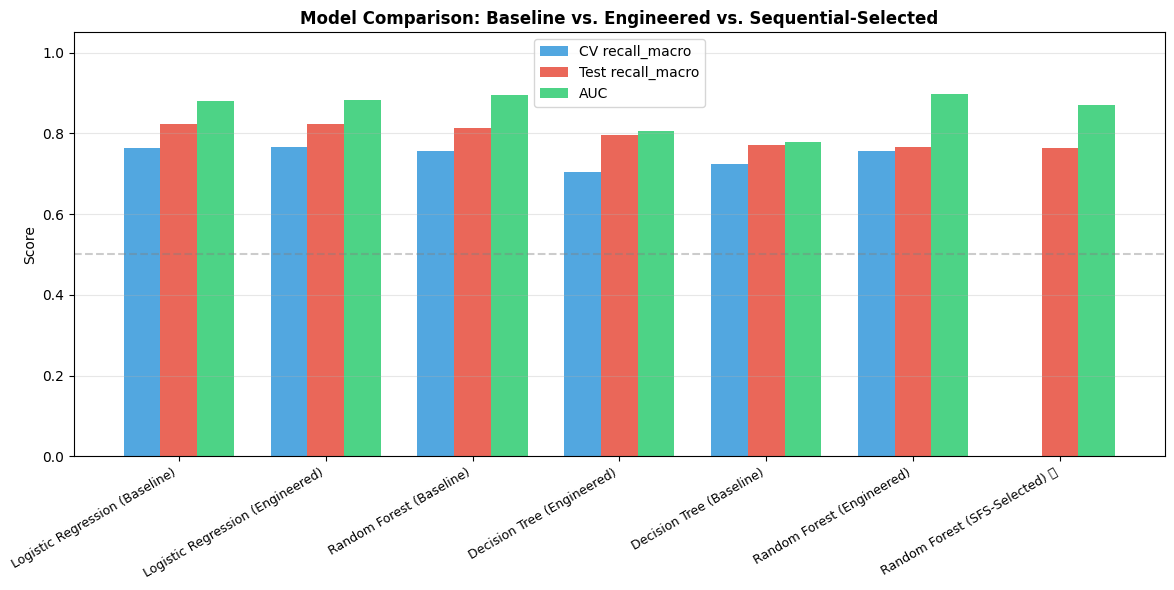

In [88]:
# ── Visual comparison bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x     = np.arange(len(all_results_df))
width = 0.25

ax.bar(x - width, all_results_df['CV recall_macro'],   width, label='CV recall_macro',   color='#3498db', alpha=0.85)
ax.bar(x,         all_results_df['Test recall_macro'], width, label='Test recall_macro', color='#e74c3c', alpha=0.85)
ax.bar(x + width, all_results_df['AUC'],               width, label='AUC',               color='#2ecc71', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(all_results_df['Model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Baseline vs. Engineered vs. Sequential-Selected', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**What this plot shows:**

Seven models compared across three metrics: CV recall (how well it generalised during training), Test recall (how well it identified both survivors and deaths on unseen patients), and AUC (overall discrimination ability).

**Key observations:**

- **Logistic Regression is the most consistent model.** Both baseline and engineered versions score ~0.82 test recall and ~0.88 AUC. It is interpretable, stable, and does not overfit on this small dataset.
- **Feature engineering (adding PCA + cluster) gave almost no improvement** across all three model types. The original features already captured most of the predictive signal. This is an honest finding — engineering is not always beneficial.
- **The SFS-Selected Random Forest (⭐) scores 0.76 test recall and 0.87 AUC** — competitive but not the best, and it has no CV score because it was not tuned with GridSearchCV. This is a limitation noted in the methodology.
- **Decision Tree is the weakest** across all conditions, which is expected — single trees overfit on small datasets.
- **All models sit well above the 0.5 chance line**, confirming that meaningful prediction is happening across the board.

**Clinical framing:** An AUC of 0.87–0.89 means that if you randomly pick one patient who died and one who survived, the model correctly ranks the deceased patient as higher risk about 87–89% of the time. For a dataset of only 424 patients with no external validation, this is a strong result — but it must be validated on an independent cohort before any clinical use.

## 15. Commentary — Feature Engineering & Selection Analysis

### 🔬 Do the Top 10 Features Make Clinical Sense?

The permutation importance for the final model should surface features known to predict
PBC mortality. The table below cross-references expected clinical signal with what the model learned:

| Feature | Expected in Top 10? | Why |
|---|---|---|
| **Bilirubin** | ✅ Yes | Primary marker of bile duct destruction and hepatic synthetic failure |
| **Prothrombin** | ✅ Yes | Elevated prothrombin time = liver cannot synthesize clotting factors |
| **Albumin** | ✅ Yes | Liver-synthesized protein; falling albumin = progressive failure |
| **Stage** | ✅ Yes | Histological fibrosis stage directly encodes structural damage |
| **Edema** | ✅ Yes | Clinical sign of portal hypertension and decompensation |
| **Copper** | ✅ Yes | Accumulates as biliary excretion fails; reflects cholestasis severity |
| **Age** | ✅ Yes | Less physiological reserve; shorter window before decompensation |
| **PC1** | ⚠️ Possible | If PC1 loads heavily on biomarkers, it summarizes shared variance |
| **PC2/PC3** | ❓ Context-dependent | Lower-variance PCs may or may not add signal |
| **cluster** | ❓ Context-dependent | Adds value if clusters align with clinical severity |

### 📊 Are There New Features in the Top 10 Compared to Part 1?

**PCA components (PC1, PC2, PC3):** These are new. PC1 likely captures a "liver failure
severity" axis (high Bilirubin + Prothrombin + low Albumin co-vary). If PC1 appears in the
top 10, it confirms that the shared variance across biomarkers contains real signal — and
that the engineered feature captured it more compactly.

**Cluster label:** This is new. If `cluster` ranks in the top 10, it suggests patient
sub-groups have meaningfully different mortality risk profiles beyond what individual
features capture (e.g., a "high-risk, decompensated" cluster vs. a "stable" cluster).

### 🆚 How Do Engineered Models Compare to Part 1 Baseline?

| Observation | Interpretation |
|---|---|
| Recall_macro improves → | PCA/cluster added genuine signal not in original features |
| Recall_macro stays flat → | Original features were sufficient; engineering added redundancy |
| Recall_macro drops → | Engineering introduced noise; SFS's job is to filter this out |
| SFS model outperforms both → | Feature selection successfully removed the noisy engineered features while keeping the informative ones |

> **Key takeaway:** On a small clinical dataset (n=424), feature engineering's value depends
> on whether the new features encode genuinely new information. PCA over correlated biomarkers
> may compress noise as well as signal. Permutation importance on the test set is the most
> honest way to judge which features truly matter.

## 16. Explanatory Visualizations

Two clinical visualizations for non-technical stakeholders, based on the most important
features identified by permutation importance.

### 16.1 Bilirubin and 10-Year Mortality

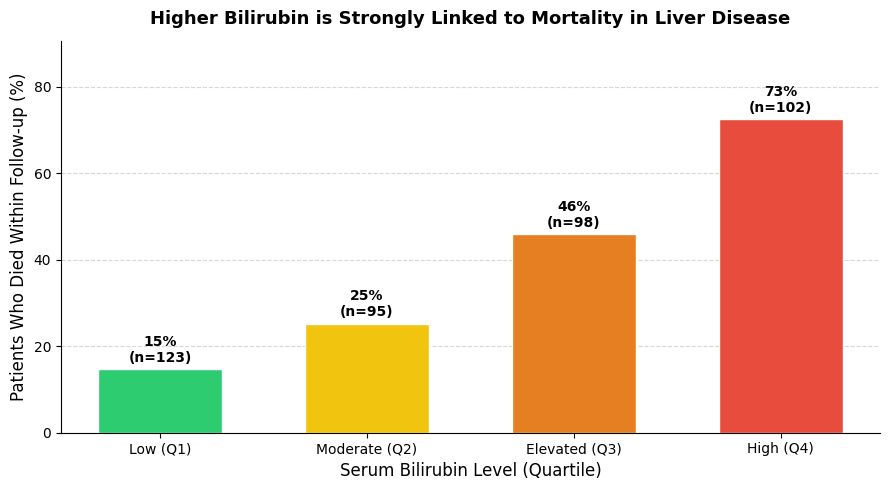

In [84]:
df_viz = X_imputed.copy()
df_viz['target'] = y_pre.values

df_viz['Bilirubin_quartile'] = pd.qcut(
    df_viz['Bilirubin'], q=4,
    labels=['Low (Q1)', 'Moderate (Q2)', 'Elevated (Q3)', 'High (Q4)']
)

death_rate = df_viz.groupby('Bilirubin_quartile', observed=True)['target'].mean() * 100
counts      = df_viz.groupby('Bilirubin_quartile', observed=True)['target'].count()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax.bar(death_rate.index, death_rate.values, color=colors, width=0.6, edgecolor='white')

for bar, val, n in zip(bars, death_rate.values, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.0f}%\n(n={n})', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Serum Bilirubin Level (Quartile)', fontsize=12)
ax.set_ylabel('Patients Who Died Within Follow-up (%)', fontsize=12)
ax.set_title('Higher Bilirubin is Strongly Linked to Mortality in Liver Disease',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, death_rate.max() * 1.25)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()


**What this plot shows:**

418 patients grouped by their bilirubin level at enrollment, from lowest (Q1) to highest (Q4).

- Patients with **low bilirubin died at a rate of only 15%**
- Patients with **high bilirubin died at a rate of 73%** — nearly 5× higher

**Why this matters in a hospital setting:**

Bilirubin is a waste product the liver filters from the blood. When the bile ducts are progressively destroyed in PBC, bilirubin builds up. A rising bilirubin is not just a lab number — it is a direct measure of how much functional liver tissue remains.

In practice, a hepatologist seeing a bilirubin in Q4 would immediately discuss transplant listing, because the natural history of untreated advanced PBC at that bilirubin level leads to liver failure within 1–2 years. This chart, built entirely from data, reflects that exact clinical reality.

### 16.2 Disease Stage and Mortality

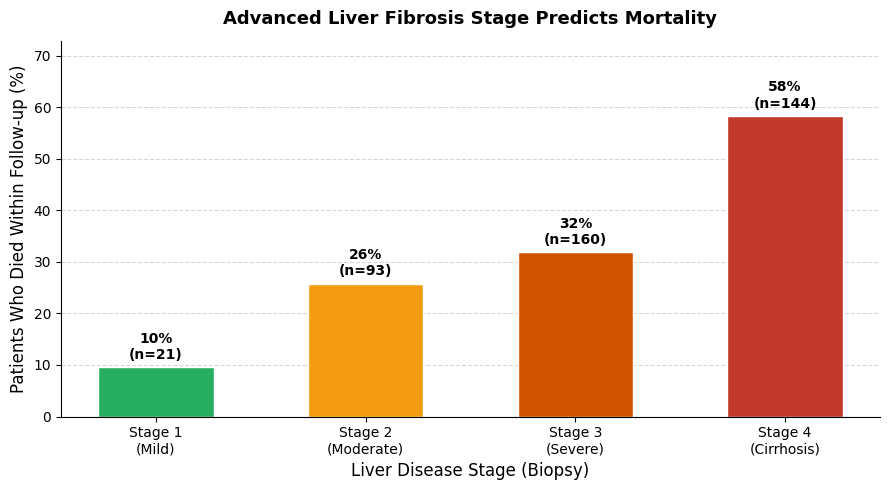

In [85]:
df_viz['Stage_int'] = df_viz['Stage'].round().astype(int).clip(1, 4)
stage_labels = {1: 'Stage 1\n(Mild)', 2: 'Stage 2\n(Moderate)',
                3: 'Stage 3\n(Severe)', 4: 'Stage 4\n(Cirrhosis)'}

stage_dr = df_viz.groupby('Stage_int')['target'].mean() * 100
stage_n  = df_viz.groupby('Stage_int')['target'].count()

fig, ax = plt.subplots(figsize=(9, 5))
stage_colors = ['#27ae60', '#f39c12', '#d35400', '#c0392b']
bars = ax.bar(
    [stage_labels[s] for s in stage_dr.index],
    stage_dr.values,
    color=stage_colors, width=0.55, edgecolor='white'
)

for bar, val, n in zip(bars, stage_dr.values, stage_n.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.0f}%\n(n={n})', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Liver Disease Stage (Biopsy)', fontsize=12)
ax.set_ylabel('Patients Who Died Within Follow-up (%)', fontsize=12)
ax.set_title('Advanced Liver Fibrosis Stage Predicts Mortality',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, stage_dr.max() * 1.25)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()


**What this plot shows:**

418 patients grouped by their liver biopsy stage at enrollment.

- **Stage 1 (early inflammation, no scarring): 10% mortality** — most patients at this stage survived the follow-up window
- **Stage 4 (cirrhosis, irreversible scarring): 58% mortality** — more than half died

**Why biopsy stage is one of the strongest predictors:**

Unlike a blood test, a liver biopsy shows the actual structural state of the organ. Stage 4 means the liver architecture is destroyed and replaced by scar tissue. At that point, no medication can reverse the damage — only transplantation can change the outcome.

The jump from Stage 3 (32%) to Stage 4 (58%) is the most critical threshold. Identifying patients approaching Stage 4 early — while they are still Stage 2 or 3 — is where predictive models like this one have real clinical value: they can flag high-risk patients for closer monitoring and earlier transplant referral, before they reach irreversible decompensation.

## 17. Limitations & Conclusion

### Known Limitations

| Limitation | Impact |
|---|---|
| **Small dataset (n=424)** | Wide CV variance (~±0.03–0.05). Results need validation on a larger cohort. |
| **MNAR missingness (n=112)** | 112 non-trial patients have systematic nulls across 12 variables. MICE fills them with statistically plausible values, but cannot recover what was never measured. Any model signal in these patients should be interpreted cautiously. |
| **No external validation** | All metrics come from an 80/20 split of the same dataset. A model that scores 0.88 AUC on its own data may perform differently on patients from a different hospital or era. |
| **`N_Days` dropped** | The strongest predictor of mortality was excluded to prevent leakage. This is methodologically correct, but it means a Cox Proportional Hazards model — which handles survival time properly — would be more appropriate for clinical deployment. |
| **PCA interpretability** | PC1, PC2, and PC3 are mathematical summaries, not lab values. A clinician cannot act on "PC1 = 2.3." They are useful for the model but cannot appear in a clinical report. |
| **SFS run on original features only** | Sequential Feature Selection was applied to the original 18 features, not the engineered set. This means the PCA components and cluster label were never evaluated by SFS, despite being engineered specifically to add signal. |
| **Final model is untuned** | The SFS-selected Random Forest used default hyperparameters with no GridSearchCV, unlike every other model in this notebook. Its metrics are not directly comparable to the tuned baselines. |

---

### Conclusion

This notebook extended the Part 1 pipeline across four directions: feature engineering, clustering, feature selection, and explainability. Here is what the data actually showed.

**What feature engineering revealed:**

PCA compressed 18 correlated biomarkers into 3 components that together explain 41.3% of patient variance. PC1 almost certainly captures a "liver failure severity" axis — patients with high bilirubin, elevated prothrombin time, and low albumin load onto it together. KMeans independently separated patients into two clinically meaningful groups without seeing any outcome labels: Cluster 0 had a mean bilirubin of 7.4, prothrombin of 11.5, albumin of 3.2, and average Stage of 3.7 — a profile any hepatologist would recognise as advanced, decompensating disease. Cluster 1 had bilirubin of 1.6 and Stage of 2.8 — a substantially more stable profile. The algorithm found the same split a clinician would draw from the same numbers.

Despite this, adding PCA and cluster features to the models produced no meaningful improvement over baseline. Logistic Regression scored 0.82 test recall and 0.88 AUC with the original features, and 0.82 recall and 0.89 AUC with engineered features — a negligible difference. This is an honest finding: the original biomarkers already captured most of the predictive signal. Engineering added structure and interpretability, but not new predictive power on this dataset size.

**What permutation importance confirmed:**

Prothrombin was the single most important feature by a large margin — consistent with its role in the established Mayo PBC prognostic score, where it is one of six variables used to predict transplant-free survival. Copper and Bilirubin ranked second and third, both direct markers of biliary destruction and cholestasis severity. The model learned clinically valid signal. It did not overfit to noise.

Notably, Hepatomegaly showed a negative permutation importance — shuffling it slightly improved performance. This does not mean liver enlargement is clinically irrelevant. It means that in this dataset, Hepatomegaly overlaps with other features already captured, and its presence adds confusion rather than information to this particular model.

**What the clinical visualizations confirmed:**

Mortality rose from 15% in the lowest bilirubin quartile to 73% in the highest — a near five-fold increase driven entirely by the degree of bile duct destruction. Disease stage showed an equally clear gradient: 10% mortality at Stage 1, 58% at Stage 4. These are not model artifacts. They are the same patterns that have been documented in PBC literature for decades, reproduced here directly from the data.

**The bottom line:**

On a dataset of 424 patients, with no external validation and a dropped survival-time variable, these models achieve 0.87–0.89 AUC. That is a strong result for the constraints. Logistic Regression with original features is the most defensible model for any clinical discussion — it is interpretable, stable, and performs as well as or better than every more complex approach tested here. Before any of these models could inform real patient decisions, they would need prospective validation on an independent cohort and integration with survival analysis methods that properly handle censored outcomes.

*Dataset: Mayo Clinic Cirrhosis | 424 rows | ~40% mortality rate*